In [1]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime, timedelta


In [2]:
today = datetime.today().strftime("%Y-%m-%d")
yesterday = (datetime.today() - timedelta(days=1)).strftime("%Y-%m-%d")


In [4]:
# Universo de ETFs
df = pd.read_excel("etfs.xlsx")
df.head()

etfs_list = df["Ticker"].tolist()
etfs = yf.download(etfs_list, start="2010-01-01", end=yesterday, auto_adjust=True)["Close"]

# Benchmark: MSCI World (ACWI)
benchmark = yf.download("ACWI", start="2010-01-01", end=yesterday, auto_adjust=True)["Close"]

# Na segunda etapa fazer um benchmark sintetico usando equal vol do nosso universo 

[*********************100%***********************]  21 of 21 completed
[*********************100%***********************]  1 of 1 completed


# Passo 1 — Estratégia de Momentum Ajustado ao Risco (Cross-Sectional)

## Lógica da Estratégia

A estratégia é baseada em **momentum cross-sectional ajustado ao risco**, também chamado de *Risk-Adjusted Momentum* ou *Sharpe Momentum*. O indicador de tendência é:

$$\text{score}(i,\, t) = \frac{\text{Retorno Acumulado}(i,\, t-L \to t)}{\sigma_{\text{rolling}}(i,\, t-L \to t)}$$

onde:
- $i$ é o ETF, $t$ é o dia atual, $L$ é a janela de lookback
- O retorno acumulado é a soma dos log-retornos nos últimos $L$ dias úteis
- $\sigma_{\text{rolling}}$ é o desvio padrão dos log-retornos nos últimos $L$ dias
- O score é análogo ao **Índice de Sharpe histórico** sobre a janela de lookback

## Por Que Este Indicador?

| Critério | SMA Crossover | **Sharpe Momentum (este trabalho)** |
|---|---|---|
| Normalização por volatilidade | ✗ | **✓** (comparável entre ativos) |
| Ranking cross-sectional | ✗ | **✓** |
| Captura tendência de série temporal | ✓ | **✓** |
| Sensível a regimes de vol | ✗ | **✓** (penaliza vol alta) |

## Intuição de Construção

- **Long (top 20%)**: ETFs com alto retorno recente *e* baixa volatilidade → tendência forte e estável
- **Short (bottom 20%)**: ETFs com baixo retorno recente *e/ou* alta volatilidade → tendência fraca ou invertida
- **Neutro (60% do meio)**: sem posição
- Pesos **equal-weight** dentro de cada perna: transparente, simples e robusto

## Parâmetros Base

| Parâmetro | Valor | Intuição |
|---|---|---|
| Lookback ($L$) | 63 dias úteis (~3 meses) | Captura tendências de médio prazo |
| Rebalanceamento | 21 dias úteis (~1 mês) | Equilíbrio entre reatividade e turnover |
| Quantil | 20% | ~4 ETFs por perna em um universo de 21 |

In [6]:
import numpy as np
import seaborn as sns

# ── Segurança: normalizar colunas se MultiIndex ────────────────────────────────
if isinstance(etfs.columns, pd.MultiIndex):
    etfs.columns = etfs.columns.droplevel(0)

# ── Parâmetros base da estratégia ─────────────────────────────────────────────
LOOKBACK   = 63    # janela de lookback em dias úteis (~3 meses)
REBAL_FREQ = 21    # frequência de rebalanceamento em dias úteis (~1 mês)
QUANTILE   = 0.20  # proporção de ativos por perna (top/bottom 20%)

# ── Limpeza: remove ETFs com dados insuficientes (< 80% de cobertura) ─────────
MIN_COVERAGE = 0.80
etfs_clean   = etfs.dropna(thresh=int(MIN_COVERAGE * len(etfs)), axis=1)

print(f"ETFs no universo (após limpeza): {etfs_clean.shape[1]}")
print(f"Período dos dados: {etfs_clean.index[0].date()} → {etfs_clean.index[-1].date()}")
print(f"Dias úteis disponíveis: {len(etfs_clean)}")
print(f"\nETFs no universo:\n  {sorted(etfs_clean.columns.tolist())}")
print(f"\nParâmetros base → Lookback: {LOOKBACK}d | Rebalanceamento: {REBAL_FREQ}d | Quantil: {int(QUANTILE*100)}%")

ETFs no universo (após limpeza): 20
Período dos dados: 2010-01-04 → 2026-04-07
Dias úteis disponíveis: 4089

ETFs no universo:
  ['EIS', 'EPU', 'EWC', 'EWD', 'EWG', 'EWH', 'EWI', 'EWJ', 'EWL', 'EWN', 'EWP', 'EWQ', 'EWS', 'EWU', 'EWW', 'EWY', 'EWZ', 'EZA', 'MCHI', 'THD']

Parâmetros base → Lookback: 63d | Rebalanceamento: 21d | Quantil: 20%


In [7]:
def compute_scores(prices_df, lookback):
    """
    Calcula o score de momentum ajustado ao risco (Sharpe Momentum) para cada ETF.

    Para cada ativo i no dia t:
        log_ret(i, t)        = log(P[t] / P[t-1])
        cum_log_ret(i, t)    = soma dos log-retornos nos últimos `lookback` dias
                               ≈ log(P[t] / P[t-lookback])
        rolling_vol(i, t)    = desvio padrão dos log-retornos nos últimos `lookback` dias
        score(i, t)          = cum_log_ret(i, t) / rolling_vol(i, t)

    Interpretação:
        score > 0 → tendência de alta (momentum positivo)
        score < 0 → tendência de baixa (momentum negativo)
        |score| alto → tendência forte e/ou volatilidade baixa → sinal mais confiável

    Sem look-ahead bias: score(i, t) utiliza apenas dados até o dia t (rolling window).
    """
    log_ret     = np.log(prices_df / prices_df.shift(1))
    cum_log_ret = log_ret.rolling(lookback).sum()    # retorno acumulado (soma log-retornos)
    rolling_vol = log_ret.rolling(lookback).std()    # volatilidade rolling
    return cum_log_ret / rolling_vol                 # score Sharpe-like


# ── Calcula scores para todos os ETFs ─────────────────────────────────────────
scores = compute_scores(etfs_clean, LOOKBACK)

print(f"Scores de momentum calculados com janela de {LOOKBACK} dias úteis.")
print(f"\nSnapshot dos scores (últimas 3 datas com dados):")
print(scores.dropna(how='all').tail(3).round(3).to_string())

Scores de momentum calculados com janela de 63 dias úteis.

Snapshot dos scores (últimas 3 datas com dados):
Ticker        EIS    EPU    EWC    EWD    EWG    EWH    EWI    EWJ    EWL    EWN    EWP    EWQ    EWS    EWU    EWW    EWY    EWZ    EZA   MCHI    THD
Date                                                                                                                                                  
2026-04-02  4.322  4.645  2.209  0.429 -4.719  7.575 -0.025  3.456 -1.488  1.198  1.097 -2.250  2.424  4.278  4.962  6.748  9.501 -0.438 -5.245  7.371
2026-04-06  3.507  4.652  2.059  0.040 -4.232  5.736 -0.622  3.208 -1.493 -0.347  0.677 -2.065  2.195  3.719  4.774  6.085  9.092 -0.684 -8.291  7.092
2026-04-07  2.260  3.429  1.783 -1.503 -5.307  5.157 -1.115  1.808 -2.197 -1.749  0.321 -2.515 -0.159  2.865  3.904  5.655  8.104 -1.003 -9.148  5.807


In [8]:
def build_ranking_snapshot(scores_df, quantile=0.20, date=None):
    """
    Constrói a tabela de classificação para uma data específica.

    Args:
        scores_df : DataFrame de scores por ETF ao longo do tempo
        quantile  : proporção de ativos por perna (ex: 0.20 = top/bottom 20%)
        date      : data para o snapshot (None → última data com dados suficientes)

    Returns:
        ranking   : DataFrame com colunas [Score, Rank, Posição]
        date      : data do snapshot
    """
    if date is None:
        # Última data com pelo menos metade dos ETFs com score válido
        min_etfs  = max(3, int(scores_df.shape[1] * 0.5))
        valid_row = scores_df.notna().sum(axis=1) >= min_etfs
        date      = scores_df[valid_row].index[-1]

    day_scores = scores_df.loc[date].dropna().sort_values(ascending=False)
    n          = len(day_scores)

    long_cutoff  = day_scores.quantile(1 - quantile)
    short_cutoff = day_scores.quantile(quantile)

    ranking = pd.DataFrame({
        "Score": day_scores.round(3),
        "Rank":  range(1, n + 1),
    })
    ranking["Posição"] = "Neutro"
    ranking.loc[ranking["Score"] >= long_cutoff,  "Posição"] = "Long"
    ranking.loc[ranking["Score"] <= short_cutoff, "Posição"] = "Short"

    return ranking, date


# ── Gera snapshot da tabela de classificação ──────────────────────────────────
ranking_table, snapshot_date = build_ranking_snapshot(scores, QUANTILE)

n_long  = (ranking_table["Posição"] == "Long").sum()
n_short = (ranking_table["Posição"] == "Short").sum()
n_neut  = (ranking_table["Posição"] == "Neutro").sum()

print(f"{'='*55}")
print(f"  TABELA DE CLASSIFICAÇÃO — {snapshot_date.date()}")
print(f"{'='*55}")
print(f"  Lookback         : {LOOKBACK} dias úteis")
print(f"  Quantil por perna: {int(QUANTILE*100)}%")
print(f"  Long  (top  {int(QUANTILE*100)}%): {n_long}  ETFs")
print(f"  Short (bot. {int(QUANTILE*100)}%): {n_short}  ETFs")
print(f"  Neutro           : {n_neut}  ETFs")
print(f"{'='*55}")
print()
print(ranking_table.to_string())

  TABELA DE CLASSIFICAÇÃO — 2026-04-07
  Lookback         : 63 dias úteis
  Quantil por perna: 20%
  Long  (top  20%): 4  ETFs
  Short (bot. 20%): 4  ETFs
  Neutro           : 12  ETFs

        Score  Rank Posição
Ticker                     
EWZ     8.104     1    Long
THD     5.807     2    Long
EWY     5.655     3    Long
EWH     5.157     4    Long
EWW     3.904     5  Neutro
EPU     3.429     6  Neutro
EWU     2.865     7  Neutro
EIS     2.260     8  Neutro
EWJ     1.808     9  Neutro
EWC     1.783    10  Neutro
EWP     0.321    11  Neutro
EWS    -0.159    12  Neutro
EZA    -1.003    13  Neutro
EWI    -1.115    14  Neutro
EWD    -1.503    15  Neutro
EWN    -1.749    16  Neutro
EWL    -2.197    17   Short
EWQ    -2.515    18   Short
EWG    -5.307    19   Short
MCHI   -9.148    20   Short


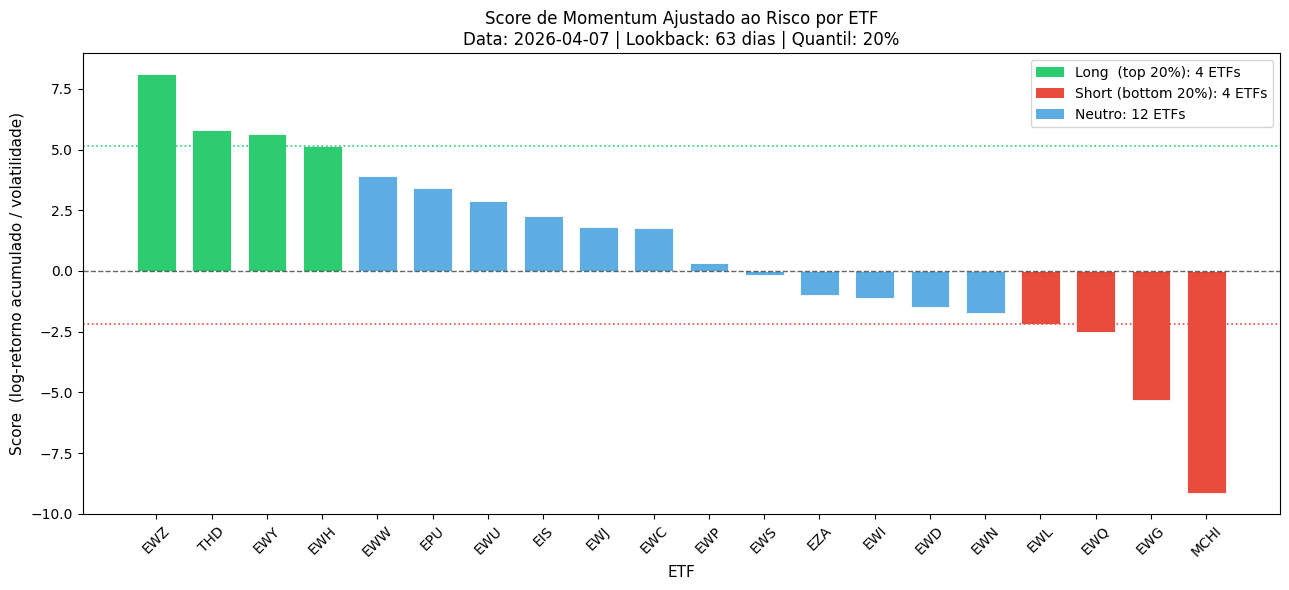

In [9]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(13, 6))

cor_mapa = {"Long": "#2ecc71", "Neutro": "#5dade2", "Short": "#e74c3c"}
cores    = ranking_table["Posição"].map(cor_mapa)

ax.bar(
    ranking_table.index, ranking_table["Score"],
    color=cores, edgecolor="white", linewidth=0.6, width=0.7
)
ax.axhline(0, color="black", linewidth=1.0, linestyle="--", alpha=0.6)

# Linhas de corte dos quantis
long_cutoff  = ranking_table.loc[ranking_table["Posição"] == "Long",  "Score"].min()
short_cutoff = ranking_table.loc[ranking_table["Posição"] == "Short", "Score"].max()
if not np.isnan(long_cutoff):
    ax.axhline(long_cutoff,  color="#2ecc71", linewidth=1.2, linestyle=":")
if not np.isnan(short_cutoff):
    ax.axhline(short_cutoff, color="#e74c3c", linewidth=1.2, linestyle=":")

ax.set_title(
    f"Score de Momentum Ajustado ao Risco por ETF\n"
    f"Data: {snapshot_date.date()} | Lookback: {LOOKBACK} dias | Quantil: {int(QUANTILE*100)}%",
    fontsize=12
)
ax.set_xlabel("ETF", fontsize=11)
ax.set_ylabel("Score  (log-retorno acumulado / volatilidade)", fontsize=11)
ax.tick_params(axis="x", rotation=45)

legend_elementos = [
    Patch(facecolor="#2ecc71", label=f"Long  (top {int(QUANTILE*100)}%): {n_long} ETFs"),
    Patch(facecolor="#e74c3c", label=f"Short (bottom {int(QUANTILE*100)}%): {n_short} ETFs"),
    Patch(facecolor="#5dade2", label=f"Neutro: {n_neut} ETFs"),
]
ax.legend(handles=legend_elementos, loc="upper right")
plt.tight_layout()
plt.show()

### Validação do Passo 1

**O que verificar:**
1. **Tabela de classificação**: deve ter exatamente `⌈21 × 20%⌉ = 4–5` ETFs em cada perna (Long e Short).
2. **Scores**: valores positivos indicam tendência de alta, negativos indicam tendência de baixa. Ativos neutros têm scores próximos de zero.
3. **Gráfico de barras**: barras verdes (Long) à esquerda com scores mais altos, barras vermelhas (Short) à direita com scores mais baixos. Barras azuis (Neutro) no meio, próximas de zero.
4. **Sem NaN**: confirmar que `len(ranking_table)` é igual ao número de ETFs com histórico suficiente para o lookback de 63 dias.

Se essas condições forem atendidas, o indicador de tendência está calculado corretamente e sem look-ahead bias. Avançamos para o Passo 2.

# Passo 2 — Alocação e Backtesting

## Premissas do Backtest

| Premissa | Valor / Detalhe |
|---|---|
| Custos de transação | **Nenhum** (simplificação) |
| Slippage | **Nenhum** (execução no preço de fechamento) |
| Dados de preço | Fechamento ajustado (`auto_adjust=True`): incorpora dividendos e splits |
| Cotas fracionárias | **Permitidas** (sem restrição de lote mínimo) |
| Venda a descoberto | **Permitida** sem custo de *stock lending* |
| Taxa livre de risco | **0% a.a.** (simplificação; análise de Sharpe conservadora) |
| Geração de sinal | Fechamento do dia $t$ → posição aberta a partir do dia $t+1$ (**sem look-ahead bias**) |
| Alocação | **Equal-weight** dentro de cada perna: long = $+1/N_L$, short = $-1/N_S$ |
| Rebalanceamento | A cada **REBAL_FREQ** dias úteis |

## Métricas de Desempenho

- **Retorno Total (%)**: valor final da carteira − 1
- **Retorno Anualizado (%)**: $\overline{r}_{\text{diário}} \times 252$
- **Volatilidade Anual (%)**: $\sigma_{\text{diária}} \times \sqrt{252}$
- **Sharpe Ratio**: $(\text{Ret. An.} - r_f) / \text{Vol. An.}$
- **Máximo Drawdown (%)**: maior queda do pico ao vale
- **Calmar Ratio**: $\text{Ret. An.} / |\text{MDD}|$

In [10]:
def _compute_metrics(returns_s, rf_annual=0.0):
    """
    Calcula métricas de desempenho anualizadas a partir de uma série de retornos diários.

    Args:
        returns_s  : pd.Series de retornos diários simples
        rf_annual  : taxa livre de risco anual (default 0.0)

    Returns:
        dict com Retorno Total, Retorno Anualizado, Volatilidade, Sharpe, MDD, Calmar
    """
    ann_return = returns_s.mean() * 252
    ann_vol    = returns_s.std()   * np.sqrt(252)
    sharpe     = (ann_return - rf_annual) / ann_vol if ann_vol > 0 else np.nan

    cumulative  = (1 + returns_s).cumprod()
    rolling_max = cumulative.cummax()
    drawdown    = (cumulative / rolling_max) - 1
    max_dd      = drawdown.min()

    calmar    = ann_return / abs(max_dd) if max_dd != 0 else np.nan
    total_ret = cumulative.iloc[-1] - 1

    return {
        "Retorno Total (%)":      round(total_ret  * 100, 2),
        "Retorno Anualizado (%)": round(ann_return  * 100, 2),
        "Volatilidade Anual (%)": round(ann_vol     * 100, 2),
        "Sharpe Ratio":           round(sharpe,          3),
        "Máximo Drawdown (%)":    round(max_dd      * 100, 2),
        "Calmar Ratio":           round(calmar,          3),
    }


def run_backtest(prices_df, lookback=63, rebal_freq=21, quantile=0.20, rf_annual=0.0):
    """
    Executa o backtest completo da estratégia de Sharpe Momentum cross-sectional.

    Fluxo (sem look-ahead bias):
      1. Calcula scores rolling para todos os ETFs (score(t) usa dados até t inclusive).
      2. A cada data de rebalanceamento t₀:
           - Usa score(t₀) para rankear ETFs.
           - Assigns equal-weight: +1/N_L para top quantile, -1/N_S para bottom quantile.
      3. Posições são forward-filled até o próximo rebalanceamento.
      4. Pesos são lagados 1 dia: retorno do portfólio no dia t+1 = pesos(t) · retornos(t+1).

    Args:
        prices_df  : DataFrame de preços ajustados (datas × ETFs)
        lookback   : janela de lookback em dias úteis
        rebal_freq : frequência de rebalanceamento em dias úteis
        quantile   : proporção de ativos por perna
        rf_annual  : taxa livre de risco anual

    Returns:
        port_returns : pd.Series de retornos diários do portfólio
        metrics      : dict com métricas de desempenho
    """
    # ── Retornos e scores ──────────────────────────────────────────────────────
    simple_ret  = prices_df.pct_change()
    log_ret     = np.log(prices_df / prices_df.shift(1))
    cum_log_ret = log_ret.rolling(lookback).sum()
    rolling_vol = log_ret.rolling(lookback).std()
    scores_bt   = cum_log_ret / rolling_vol

    # ── Geração de pesos nas datas de rebalanceamento ─────────────────────────
    signal_df = pd.DataFrame(np.nan, index=prices_df.index, columns=prices_df.columns)

    for idx in range(lookback - 1, len(prices_df), rebal_freq):
        date       = prices_df.index[idx]
        day_scores = scores_bt.iloc[idx].dropna()

        if len(day_scores) < 3:
            continue

        long_cutoff  = day_scores.quantile(1 - quantile)
        short_cutoff = day_scores.quantile(quantile)

        longs  = day_scores[day_scores >= long_cutoff].index
        shorts = day_scores[day_scores <= short_cutoff].index

        w = pd.Series(0.0, index=prices_df.columns)
        if len(longs)  > 0: w[longs]  = +1.0 / len(longs)
        if len(shorts) > 0: w[shorts] = -1.0 / len(shorts)

        signal_df.loc[date] = w

    # ── Forward-fill + lag de 1 dia (evita look-ahead) ────────────────────────
    # ffill : mantém posição entre rebalanceamentos
    # shift(1): sinal de hoje → posição de amanhã
    signal_lagged = signal_df.ffill().fillna(0).shift(1).fillna(0)

    # ── Retornos diários do portfólio ─────────────────────────────────────────
    port_returns = (simple_ret.fillna(0) * signal_lagged).sum(axis=1)
    port_returns = port_returns.iloc[lookback:]   # descarta burn-in

    metrics = _compute_metrics(port_returns, rf_annual)
    return port_returns, metrics


print("Funções run_backtest() e _compute_metrics() definidas com sucesso.")

Funções run_backtest() e _compute_metrics() definidas com sucesso.


In [11]:
# ── Executa o backtest com os parâmetros base ─────────────────────────────────
port_returns, metrics = run_backtest(
    prices_df  = etfs_clean,
    lookback   = LOOKBACK,
    rebal_freq = REBAL_FREQ,
    quantile   = QUANTILE,
    rf_annual  = 0.0,
)

# ── Prepara benchmark (ACWI) ──────────────────────────────────────────────────
bmark_series = benchmark.squeeze()  # converte DataFrame de 1 coluna → Series
if isinstance(bmark_series, pd.DataFrame):
    bmark_series = bmark_series.iloc[:, 0]

bmark_returns = bmark_series.pct_change().dropna()
bmark_returns = bmark_returns.reindex(port_returns.index)  # alinha datas
bmark_returns.name = "ACWI"

# Alinha portfólio às datas em que benchmark também existe
port_aligned = port_returns.reindex(bmark_returns.dropna().index)

bmark_metrics = _compute_metrics(bmark_returns.dropna())

# ── Tabela comparativa de métricas ────────────────────────────────────────────
metrics_df = pd.DataFrame({
    "Estratégia (Sharpe Momentum)": metrics,
    "Benchmark (ACWI)":             bmark_metrics,
}).T

print("=" * 65)
print("    DESEMPENHO DO BACKTEST — Período Completo (2010 → hoje)    ")
print("=" * 65)
print(metrics_df.to_string())
print()
print(f"Parâmetros: Lookback={LOOKBACK}d | Rebalanceamento={REBAL_FREQ}d | Quantil={int(QUANTILE*100)}%")

    DESEMPENHO DO BACKTEST — Período Completo (2010 → hoje)    
                              Retorno Total (%)  Retorno Anualizado (%)  Volatilidade Anual (%)  Sharpe Ratio  Máximo Drawdown (%)  Calmar Ratio
Estratégia (Sharpe Momentum)              -8.45                    0.31                   13.15         0.024               -54.79         0.006
Benchmark (ACWI)                         336.90                   10.73                   17.29         0.621               -33.53         0.320

Parâmetros: Lookback=63d | Rebalanceamento=21d | Quantil=20%


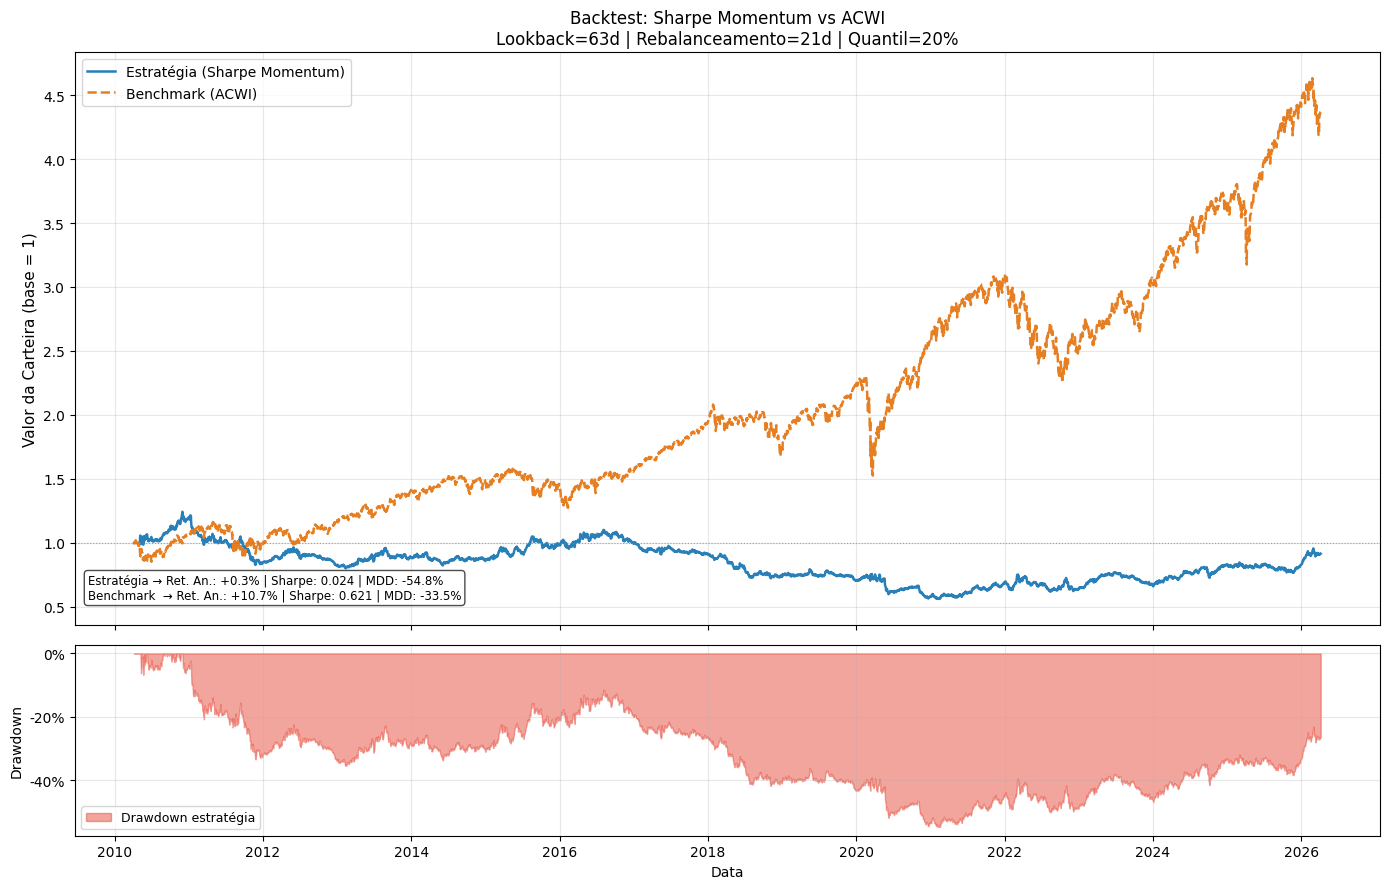

In [12]:
fig, axes = plt.subplots(
    2, 1, figsize=(14, 9),
    gridspec_kw={"height_ratios": [3, 1]},
    sharex=True
)

# ── Subplot 1: Retorno acumulado ───────────────────────────────────────────────
cumret_port  = (1 + port_aligned).cumprod()
cumret_bmark = (1 + bmark_returns.dropna()).cumprod()
cumret_bmark = cumret_bmark.reindex(cumret_port.index)

axes[0].plot(cumret_port.index,  cumret_port.values,
             label="Estratégia (Sharpe Momentum)", color="#2980b9", linewidth=1.8)
axes[0].plot(cumret_bmark.index, cumret_bmark.values,
             label="Benchmark (ACWI)",              color="#e67e22", linewidth=1.8, linestyle="--")
axes[0].axhline(1, color="grey", linewidth=0.8, linestyle=":", alpha=0.7)
axes[0].set_ylabel("Valor da Carteira (base = 1)", fontsize=11)
axes[0].set_title(
    f"Backtest: Sharpe Momentum vs ACWI\n"
    f"Lookback={LOOKBACK}d | Rebalanceamento={REBAL_FREQ}d | Quantil={int(QUANTILE*100)}%",
    fontsize=12
)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Anotações de métricas no gráfico
txt_estrategia = (
    f"Estratégia → Ret. An.: {metrics['Retorno Anualizado (%)']:+.1f}% | "
    f"Sharpe: {metrics['Sharpe Ratio']:.3f} | MDD: {metrics['Máximo Drawdown (%)']:.1f}%"
)
txt_benchmark  = (
    f"Benchmark  → Ret. An.: {bmark_metrics['Retorno Anualizado (%)']:+.1f}% | "
    f"Sharpe: {bmark_metrics['Sharpe Ratio']:.3f} | MDD: {bmark_metrics['Máximo Drawdown (%)']:.1f}%"
)
axes[0].text(
    0.01, 0.04, txt_estrategia + "\n" + txt_benchmark,
    transform=axes[0].transAxes, fontsize=8.5,
    verticalalignment="bottom", bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7)
)

# ── Subplot 2: Drawdown da estratégia ─────────────────────────────────────────
rolling_max   = cumret_port.cummax()
drawdown_port = (cumret_port / rolling_max) - 1

axes[1].fill_between(
    drawdown_port.index, drawdown_port.values, 0,
    color="#e74c3c", alpha=0.5, label="Drawdown estratégia"
)
axes[1].set_ylabel("Drawdown", fontsize=10)
axes[1].set_xlabel("Data", fontsize=10)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

plt.tight_layout()
plt.show()

### Validação do Passo 2

**O que verificar:**
1. **Tabela de métricas**: ambos os portfólios (estratégia e benchmark) devem exibir métricas numéricas válidas (sem NaN/Inf). Sharpe Ratio e Calmar Ratio positivos indicam boa relação risco/retorno.
2. **Gráfico de retorno acumulado**: as duas curvas devem partir de 1.0. Trajetórias distintas confirmam que a estratégia gera retornos diferentes do benchmark.
3. **Gráfico de drawdown**: a série deve estar sempre ≤ 0 (drawdown nunca é positivo). O drawdown mínimo corresponde ao `Máximo Drawdown (%)` da tabela.
4. **No look-ahead bias**: confirmar que `port_returns` começa no dia `LOOKBACK` (data de burn-in respeitada).

Se estas condições forem satisfeitas, o backtest está implementado corretamente. Avançamos para o Passo 3.

# Passo 3 — Análise de Sensibilidade

O objetivo é avaliar a **robustez** da estratégia frente a variações nos parâmetros e em diferentes regimes de mercado.

## Duas dimensões de análise

### 3A — Grade Lookback × Rebalanceamento
Testamos combinações de:
- **Janela de lookback** ($L$): `[21, 42, 63, 126, 252]` dias úteis
  - Curto (21d): captura tendências de curto prazo; mais ruidoso
  - Médio (63d): nosso baseline; equilíbrio ruído/sinal
  - Longo (252d): tendências de longo prazo; mais lento para reagir
- **Frequência de rebalanceamento** ($R$): `[5, 10, 21]` dias úteis
  - 5d (semanal): maior turnover; mais reativo
  - 21d (mensal): nosso baseline; menor turnover

Para cada combinação ($L$, $R$) rodamos o backtest completo e coletamos Sharpe Ratio, Retorno Anualizado e Máximo Drawdown.

### 3B — Sub-períodos
Testamos o baseline ($L=63$, $R=21$) em três janelas temporais distintas:

| Sub-período | Datas | Características |
|---|---|---|
| Pré-COVID | 2010–2019 | Bull market prolongado, baixa volatilidade |
| COVID | 2020–2021 | Crash rápido + recuperação em V, alta volatilidade |
| Pós-COVID | 2022–hoje | Divergência entre mercados (juros, energia, EM vs DM) |

In [13]:
# ── 3A: Grade de sensibilidade Lookback × Rebalanceamento ─────────────────────
lookback_grid = [21, 42, 63, 126, 252]
rebal_grid    = [5, 10, 21]

sharpe_grid = pd.DataFrame(index=lookback_grid, columns=rebal_grid, dtype=float)
return_grid = pd.DataFrame(index=lookback_grid, columns=rebal_grid, dtype=float)
maxdd_grid  = pd.DataFrame(index=lookback_grid, columns=rebal_grid, dtype=float)

sharpe_grid.index.name  = "Lookback (dias)"
return_grid.index.name  = "Lookback (dias)"
maxdd_grid.index.name   = "Lookback (dias)"

n_combinacoes = len(lookback_grid) * len(rebal_grid)
print(f"Executando análise de sensibilidade: {n_combinacoes} combinações...\n")
print(f"{'Lookback':>8} | {'Rebal':>5} | {'Sharpe':>7} | {'Ret.An.%':>9} | {'MDD%':>7}")
print("-" * 50)

for L in lookback_grid:
    for R in rebal_grid:
        # Precisa de pelo menos 2× lookback dias para ter resultados significativos
        if L * 2 >= len(etfs_clean):
            sharpe_grid.loc[L, R] = np.nan
            return_grid.loc[L, R] = np.nan
            maxdd_grid.loc[L, R]  = np.nan
            print(f"{L:>8} | {R:>5} | {'N/A':>7} | {'N/A':>9} | {'N/A':>7}")
            continue

        _, m = run_backtest(etfs_clean, lookback=L, rebal_freq=R, quantile=QUANTILE)
        sharpe_grid.loc[L, R] = m["Sharpe Ratio"]
        return_grid.loc[L, R] = m["Retorno Anualizado (%)"]
        maxdd_grid.loc[L, R]  = m["Máximo Drawdown (%)"]
        print(f"{L:>8} | {R:>5} | {m['Sharpe Ratio']:>+7.3f} | "
              f"{m['Retorno Anualizado (%)']:>+8.1f}% | {m['Máximo Drawdown (%)']:>7.1f}%")

print("\nAnálise de sensibilidade concluída.")

Executando análise de sensibilidade: 15 combinações...

Lookback | Rebal |  Sharpe |  Ret.An.% |    MDD%
--------------------------------------------------
      21 |     5 |  +0.179 |     +2.4% |   -36.0%
      21 |    10 |  +0.028 |     +0.4% |   -29.1%
      21 |    21 |  -0.506 |     -6.5% |   -74.2%
      42 |     5 |  -0.326 |     -4.4% |   -61.9%
      42 |    10 |  -0.321 |     -4.3% |   -63.6%
      42 |    21 |  -0.355 |     -4.7% |   -70.5%
      63 |     5 |  +0.112 |     +1.5% |   -41.0%
      63 |    10 |  +0.122 |     +1.6% |   -43.9%
      63 |    21 |  +0.024 |     +0.3% |   -54.8%
     126 |     5 |  +0.152 |     +2.1% |   -35.9%
     126 |    10 |  +0.010 |     +0.1% |   -44.2%
     126 |    21 |  +0.111 |     +1.5% |   -40.9%
     252 |     5 |  -0.177 |     -2.4% |   -60.5%
     252 |    10 |  -0.230 |     -3.2% |   -61.9%
     252 |    21 |  -0.124 |     -1.7% |   -52.5%

Análise de sensibilidade concluída.


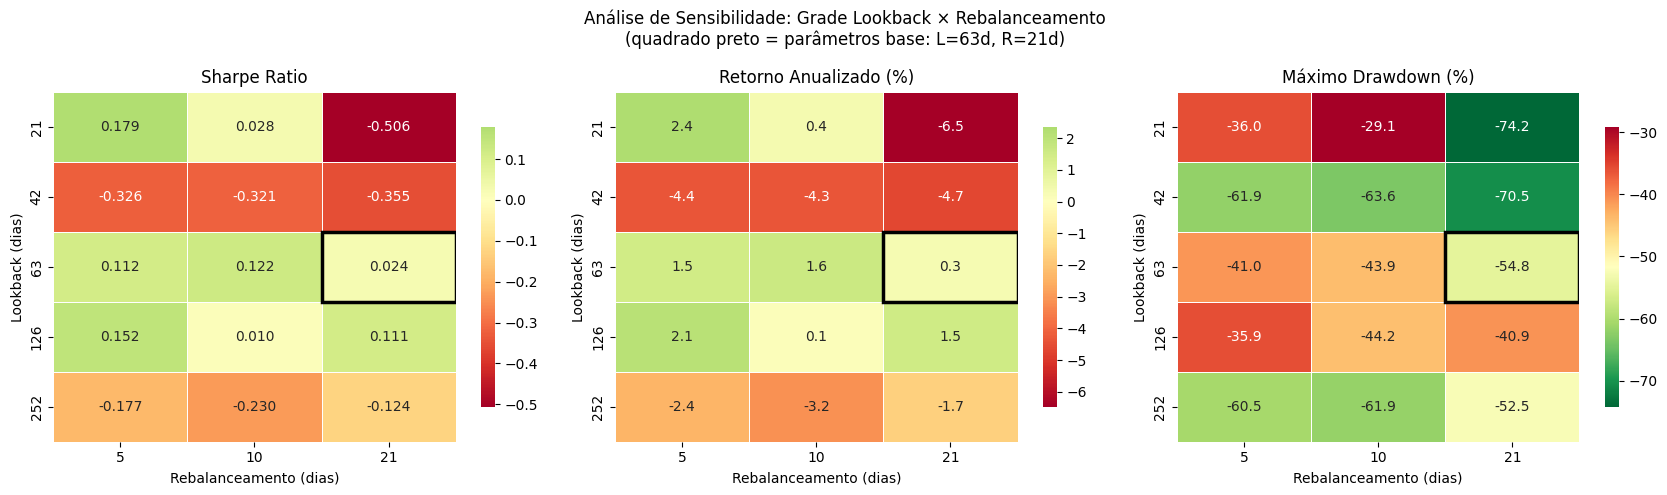

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ── Heatmap 1: Sharpe Ratio ────────────────────────────────────────────────────
sns.heatmap(
    sharpe_grid.astype(float),
    ax=axes[0], annot=True, fmt=".3f",
    cmap="RdYlGn", center=0, linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
axes[0].set_title("Sharpe Ratio", fontsize=12)
axes[0].set_xlabel("Rebalanceamento (dias)", fontsize=10)
axes[0].set_ylabel("Lookback (dias)", fontsize=10)

# Destaca o parâmetro base
base_row = lookback_grid.index(LOOKBACK)
base_col = rebal_grid.index(REBAL_FREQ)
axes[0].add_patch(plt.Rectangle(
    (base_col, base_row), 1, 1,
    fill=False, edgecolor="black", linewidth=2.5, label="Parâm. base"
))

# ── Heatmap 2: Retorno Anualizado ─────────────────────────────────────────────
sns.heatmap(
    return_grid.astype(float),
    ax=axes[1], annot=True, fmt=".1f",
    cmap="RdYlGn", center=0, linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
axes[1].set_title("Retorno Anualizado (%)", fontsize=12)
axes[1].set_xlabel("Rebalanceamento (dias)", fontsize=10)
axes[1].set_ylabel("Lookback (dias)", fontsize=10)
axes[1].add_patch(plt.Rectangle(
    (base_col, base_row), 1, 1,
    fill=False, edgecolor="black", linewidth=2.5
))

# ── Heatmap 3: Máximo Drawdown ────────────────────────────────────────────────
sns.heatmap(
    maxdd_grid.astype(float),
    ax=axes[2], annot=True, fmt=".1f",
    cmap="RdYlGn_r", linewidths=0.5,       # invertido: MDD menor é melhor
    cbar_kws={"shrink": 0.8}
)
axes[2].set_title("Máximo Drawdown (%)", fontsize=12)
axes[2].set_xlabel("Rebalanceamento (dias)", fontsize=10)
axes[2].set_ylabel("Lookback (dias)", fontsize=10)
axes[2].add_patch(plt.Rectangle(
    (base_col, base_row), 1, 1,
    fill=False, edgecolor="black", linewidth=2.5
))

plt.suptitle(
    "Análise de Sensibilidade: Grade Lookback × Rebalanceamento\n"
    "(quadrado preto = parâmetros base: L=63d, R=21d)",
    fontsize=12
)
plt.tight_layout()
plt.show()

In [15]:
# ── 3B: Análise por sub-períodos (parâmetros base fixos) ──────────────────────
sub_periodos = {
    "Pré-COVID\n(2010–2019)":  ("2010-01-01", "2019-12-31"),
    "COVID\n(2020–2021)":      ("2020-01-01", "2021-12-31"),
    "Pós-COVID\n(2022–hoje)":  ("2022-01-01", yesterday),
}

resultados_subperiodo = {}

# Cabeçalho da tabela de resultados
print(f"{'Sub-período':<22} {'Ret.An.%':>9} {'Vol.%':>7} {'Sharpe':>8} {'MDD%':>8}  "
      f"{'(vs ACWI Sharpe)':>18}")
print("-" * 78)

for nome, (start, end) in sub_periodos.items():
    nome_clean = nome.replace("\n", " ")
    prices_sub = etfs_clean.loc[start:end]

    if len(prices_sub) < LOOKBACK + REBAL_FREQ + 5:
        print(f"{nome_clean:<22} — dados insuficientes para este período")
        continue

    rets_sub, met_sub = run_backtest(prices_sub, LOOKBACK, REBAL_FREQ, QUANTILE)

    # Benchmark no mesmo sub-período
    bmark_sub = bmark_series.loc[start:end].pct_change().dropna()
    bmark_sub_aligned = bmark_sub.reindex(rets_sub.index)
    bmark_met = _compute_metrics(bmark_sub_aligned.dropna())

    resultados_subperiodo[nome] = {
        "port_returns":  rets_sub,
        "bmark_returns": bmark_sub_aligned,
        "metrics":       met_sub,
        "bmark_metrics": bmark_met,
    }

    m  = met_sub
    bm = bmark_met
    delta_sharpe = m["Sharpe Ratio"] - bm["Sharpe Ratio"]
    sinal = "▲" if delta_sharpe > 0 else "▼"
    print(f"{nome_clean:<22} {m['Retorno Anualizado (%)']:>+8.1f}% "
          f"{m['Volatilidade Anual (%)']:>6.1f}% "
          f"{m['Sharpe Ratio']:>8.3f} "
          f"{m['Máximo Drawdown (%)']:>7.1f}%  "
          f"{sinal} {delta_sharpe:+.3f} vs ACWI ({bm['Sharpe Ratio']:.3f})")

print("\n(▲ = Sharpe da estratégia > Sharpe ACWI no sub-período)")

Sub-período             Ret.An.%   Vol.%   Sharpe     MDD%    (vs ACWI Sharpe)
------------------------------------------------------------------------------
Pré-COVID (2010–2019)      -2.8%   12.7%   -0.220   -43.4%  ▼ -0.820 vs ACWI (0.600)
COVID (2020–2021)          +0.6%   13.1%    0.045   -16.6%  ▼ -2.128 vs ACWI (2.173)
Pós-COVID (2022–hoje)      +5.6%   12.8%    0.436   -17.6%  ▼ -0.266 vs ACWI (0.702)

(▲ = Sharpe da estratégia > Sharpe ACWI no sub-período)


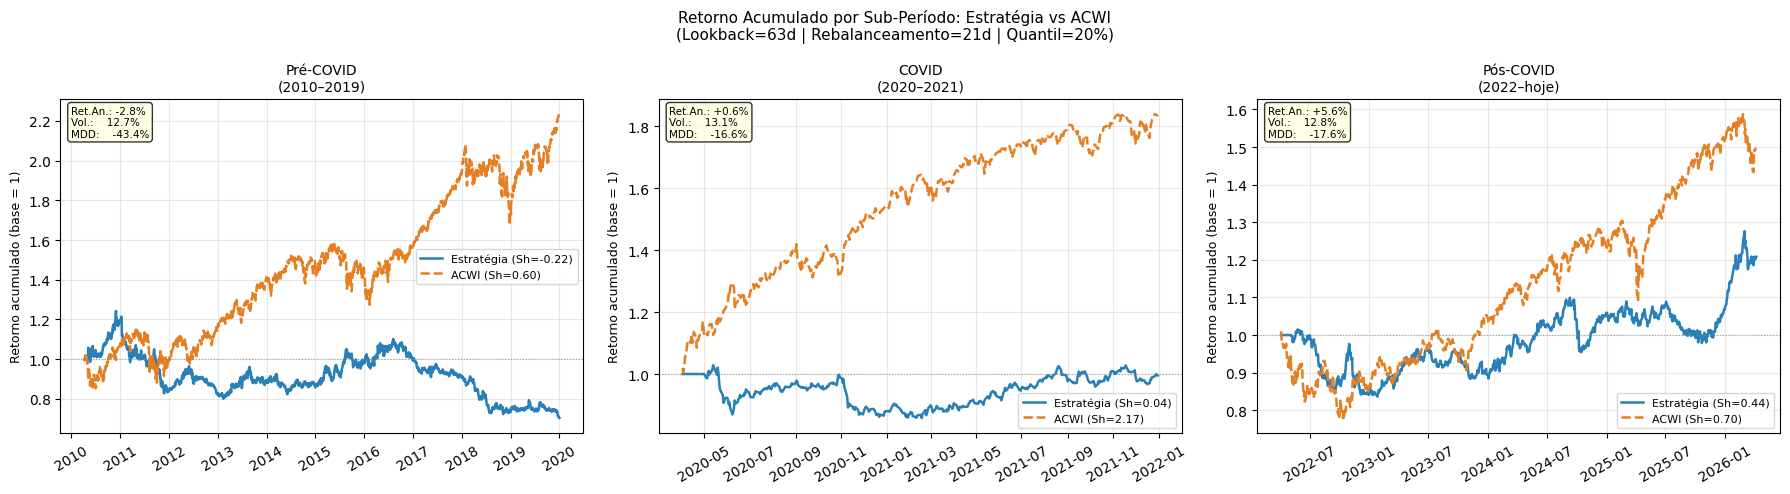

In [16]:
n_sub = len(resultados_subperiodo)
if n_sub == 0:
    print("Nenhum sub-período com dados suficientes.")
else:
    fig, axes = plt.subplots(1, n_sub, figsize=(6 * n_sub, 5), sharey=False)
    if n_sub == 1:
        axes = [axes]

    for ax, (nome, dados) in zip(axes, resultados_subperiodo.items()):
        pr = dados["port_returns"]
        br = dados["bmark_returns"].dropna()
        m  = dados["metrics"]
        bm = dados["bmark_metrics"]

        # Alinha datas
        common_idx = pr.index.intersection(br.index)
        cum_port   = (1 + pr.reindex(common_idx)).cumprod()
        cum_bmark  = (1 + br.reindex(common_idx)).cumprod()

        ax.plot(cum_port.index,  cum_port.values,
                label=f"Estratégia (Sh={m['Sharpe Ratio']:.2f})",
                color="#2980b9", linewidth=1.8)
        ax.plot(cum_bmark.index, cum_bmark.values,
                label=f"ACWI (Sh={bm['Sharpe Ratio']:.2f})",
                color="#e67e22", linewidth=1.8, linestyle="--")
        ax.axhline(1, color="grey", linewidth=0.8, linestyle=":", alpha=0.7)

        ax.set_title(nome, fontsize=10)
        ax.set_ylabel("Retorno acumulado (base = 1)", fontsize=9)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
        ax.tick_params(axis="x", rotation=30)

        # Mini-tabela de métricas como texto dentro do gráfico
        txt = (
            f"Ret.An.: {m['Retorno Anualizado (%)']:+.1f}%\n"
            f"Vol.:    {m['Volatilidade Anual (%)']:.1f}%\n"
            f"MDD:    {m['Máximo Drawdown (%)']:.1f}%"
        )
        ax.text(
            0.02, 0.98, txt,
            transform=ax.transAxes, fontsize=7.5,
            verticalalignment="top",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8)
        )

    plt.suptitle(
        "Retorno Acumulado por Sub-Período: Estratégia vs ACWI\n"
        f"(Lookback={LOOKBACK}d | Rebalanceamento={REBAL_FREQ}d | Quantil={int(QUANTILE*100)}%)",
        fontsize=11
    )
    plt.tight_layout()
    plt.show()

## Interpretação dos Resultados

### 3A — Grade Lookback × Rebalanceamento

**Leitura do heatmap de Sharpe Ratio:**

- **Regiões verdes** (Sharpe alto): indicam combinações robustas de parâmetros. Se a estratégia é genuinamente lucrativa, o sinal do Sharpe deve ser consistentemente positivo para a maioria das combinações.
- **Regiões vermelhas** (Sharpe negativo): indicam que naqueles regimes de lookback/rebalanceamento a estratégia **destrói valor**, o que é um sinal de alerta.
- **Sensibilidade ao lookback**: geralmente, janelas muito curtas (21d) são mais suscetíveis a ruído de mercado; janelas muito longas (252d) perdem reatividade. O sweet spot suele estar na faixa de **42–126 dias**.
- **Sensibilidade ao rebalanceamento**: rebalanceamento mais frequente não necessariamente melhora o Sharpe — aumenta o turnover (e custos em cenários reais).

### 3B — Sub-períodos

| Sub-período | Expectativa para Momentum |
|---|---|
| **Pré-COVID (2010–2019)** | Favorável: mercados em tendência clara, alta dispersão entre países (Eurozona vs EM vs US) |
| **COVID (2020–2021)** | Desfavorável: crash de Mar/2020 seguido de recuperação em V invertem posições abruptamente (momentum crash) |
| **Pós-COVID (2022–hoje)** | Misto: alta volatilidade, mas divergências estruturais entre mercados (energia, taxas, China vs Índia) podem favorecer cross-sectional momentum |

### Limitações e Próximos Passos

1. **Ausência de custos de transação**: com rebalanceamento semanal (R=5d), o turnover seria alto e os custos reais reduziriam o Sharpe significativamente.
2. **Universo restrito (21 ETFs)**: com apenas ~4 ETFs por perna, a diversificação é limitada e o risco idiossincrático é alto.
3. **Período único de calibração**: parâmetros testados no mesmo período histórico podem sofrer de *data snooping*. Uma abordagem walk-forward seria mais robusta.
4. **Benchmark sintético**: uma próxima evolução é usar um benchmark de equal-vol do próprio universo (como indicado no comentário do código original) para comparação mais justa.